# Pronóstico de Generación Solar - Planta "El Paso"

## Creación y análisis del dataset

### Ubicación de la Planta: El Paso, Cesar, Colombia
> **Coordenadas**: 9.785041627157241, -73.7201783147516
> La planta solar **"El Paso"** se encuentra ubicada en el departamento del Cesar, Colombia. Esta región es privilegiada por su alta radiación solar, lo que la hace ideal para la generación de energía fotovoltaica.

### Datos de Generación Real (XM)
Los registros de generación provienen de **XM**, el operador del Sistema Interconectado Nacional (SIN) en Colombia. Representan la telemedida directa instalada en la planta.

| Variable | Columna CSV | Unidad | Descripción |
| :--- | :--- | :--- | :--- |
| **Fecha** | `Fecha` | YYYY-MM-DD | Fecha del reporte de generación. |
| **Recurso** | `Recurso` | Texto | Nombre de la planta (EL PASO). |
| **Generación Horaria** | `0, 1, ..., 23` | kWh | Energía real generada en cada intervalo de una hora. |
| **Versión** | `Version` | Texto | Código de versión del dato reportado. |

El archivo de datos de XM ya existe localmente.
Generando visualizaciones...


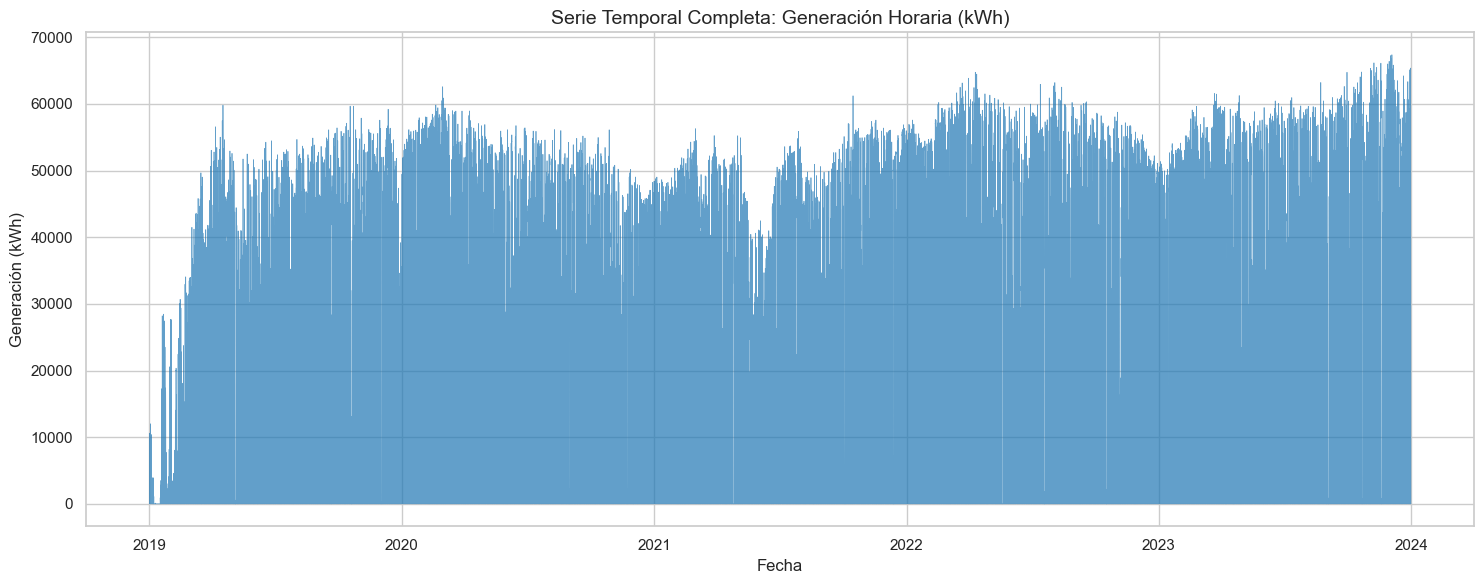

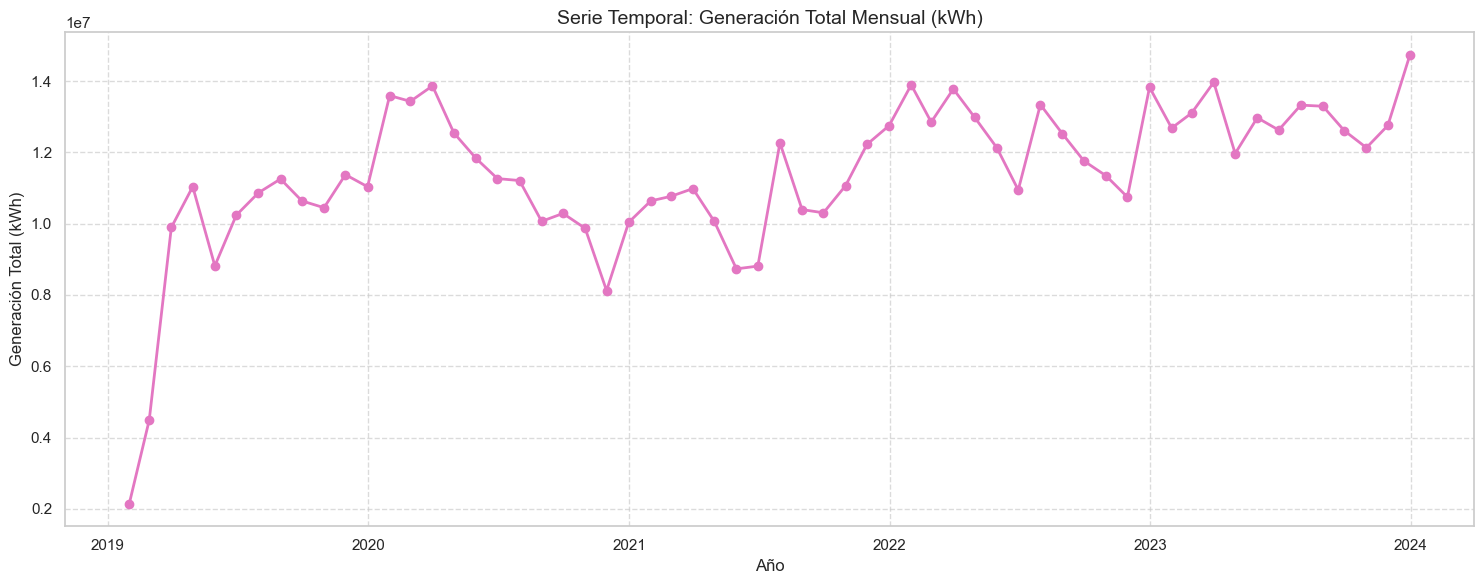

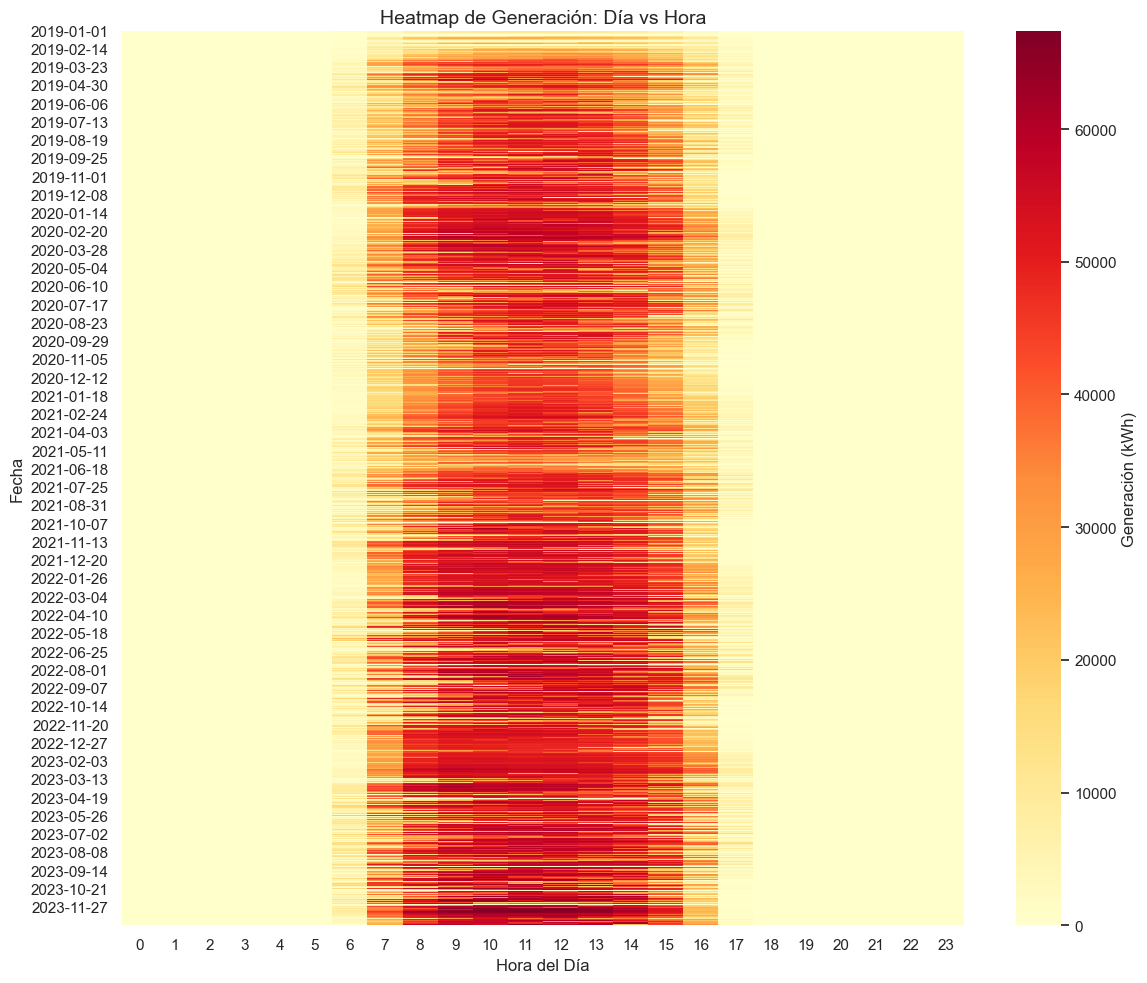

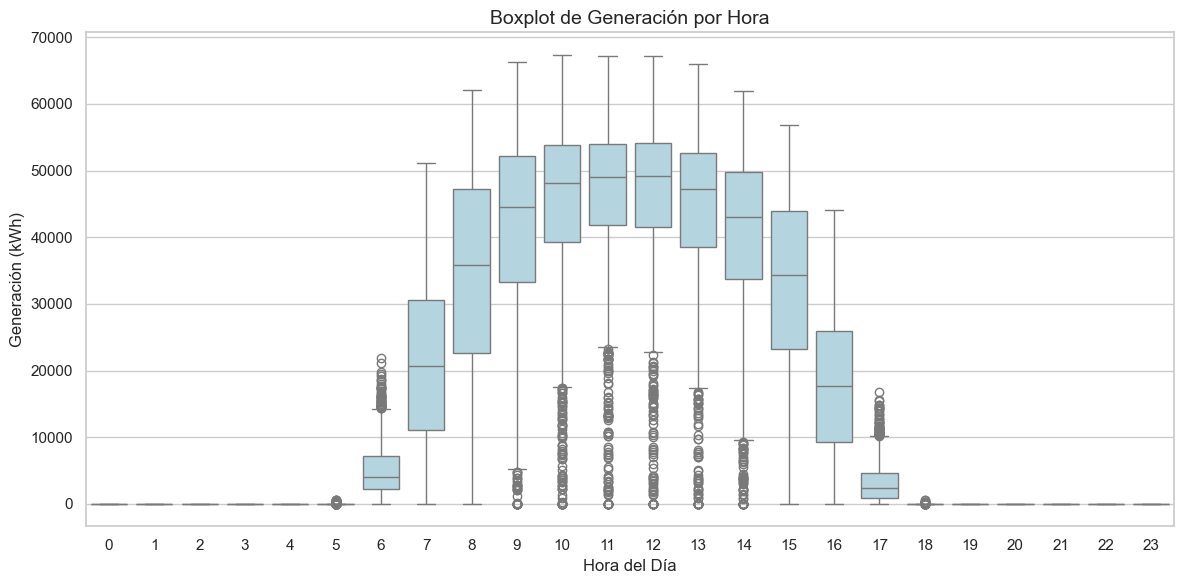

In [17]:
# Descarga de datos desde Google Drive y Análisis Exploratorio (EDA)
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

def download_file_from_google_drive(id, destination):
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={'id': id}, stream=True)
    token = None
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        params = {'id': id, 'confirm': token}
        response = session.get(URL, params=params, stream=True)
    
    with open(destination, "wb") as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)

file_id = '1XM7xrH4WCh1knxF7kTt9Mj3mx1RUGnWC'
destination = 'data/data_2019_2023_kwH_xm.csv'

if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists(destination):
    print("Descargando archivo desde Google Drive...")
    download_file_from_google_drive(file_id, destination)
    print("Descarga completada.")
else:
    print("El archivo de datos de XM ya existe localmente.")

# Cargar y preparar datos
df = pd.read_csv(destination)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed')
hours = [str(i) for i in range(24)]
df_melted = df.melt(id_vars=['Fecha'], value_vars=hours, var_name='Hora', value_name='Generacion')
df_melted['Hora'] = df_melted['Hora'].astype(int)
df_melted['Timestamp'] = df_melted['Fecha'] + pd.to_timedelta(df_melted['Hora'], unit='h')
df_melted = df_melted.sort_values('Timestamp').reset_index(drop=True)

sns.set_theme(style="whitegrid")
print("Generando visualizaciones...")

# 1. Serie Temporal Completa (Horaria)
plt.figure(figsize=(15, 6))
plt.plot(df_melted['Timestamp'], df_melted['Generacion'], color='#1f77b4', linewidth=0.5, alpha=0.7)
plt.title('Serie Temporal Completa: Generación Horaria (kWh)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Generación (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Serie Temporal Mensual Total
df_monthly_sum = df_melted.set_index('Timestamp')['Generacion'].resample('ME').sum().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(df_monthly_sum['Timestamp'], df_monthly_sum['Generacion'], marker='o', color="#e377c2", linewidth=2)
plt.title('Serie Temporal: Generación Total Mensual (kWh)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Generación Total (kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Heatmap Día vs Hora
heatmap_data = df.copy()
heatmap_data['Fecha_str'] = heatmap_data['Fecha'].dt.strftime('%Y-%m-%d')
heatmap_data = heatmap_data.set_index('Fecha_str')[hours].astype(float)
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Generación (kWh)'})
plt.title('Heatmap de Generación: Día vs Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Fecha', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Boxplot de Generación por Hora
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Hora', y='Generacion', color="lightblue")
plt.title('Boxplot de Generación por Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Generación (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis de las Visualizaciones de Generación (XM)

1. **Serie Temporal Completa**: Muestra la evolución horaria de la generación desde 2019 hasta 2023. Se observa la alternancia natural entre día y noche, así como la variabilidad interanual.
2. **Serie Temporal Mensual Total**: Al agregar los datos mensualmente, podemos identificar con mayor claridad la estacionalidad de la planta. Los picos de generación suelen coincidir con las épocas de mayor radiación solar en el departamento del Cesar.
3. **Heatmap Día vs Hora**: Esta visualización permite ver patrones de despacho. La franja central representa las horas de sol. Se puede notar cómo la intensidad varía según la época del año (estacionalidad vertical).
4. **Boxplot de Generación por Hora**: Representa la distribución de la energía generada en cada hora. Permite observar los valores máximos alcanzados al mediodía y la dispersión causada por factores climáticos (nubosidad).

### Fuentes Climáticas: NASA POWER vs Open-Meteo
Para el entrenamiento de los modelos, se evaluaron dos fuentes principales:

1. **Open-Meteo (ERA5/ERA5-Land)**: Proporciona datos de reanálisis de alta precisión
2. **NASA POWER**: Utiliza datos satelitales calibrados para energía renovable.

**¿Por qué se eligió NASA POWER?**
Aunque Open-Meteo es altamente preciso, se seleccionó **NASA POWER** como base principal para el dataset consolidado debido a que no presenta valores faltantes (nulls) en el rango de tiempo estudiado (2019-2023), lo que garantiza un entrenamiento estable sin necesidad de imputaciones complejas.

### Variables de NASA POWER Utilizadas:
| Variable API | Columna CSV | Unidad | Descripción |
| :--- | :--- | :--- | :--- |
| `ALLSKY_SFC_SW_DWN` | `Irradiancia_It` | Wh/m² | Irradiancia de onda corta hacia abajo (superficie). |
| `T2M` | `Temperatura_Tt` | °C | Temperatura a 2 metros. |
| `RH2M` | `Humedad_Ht` | % | Humedad relativa a 2 metros. |
| `WS10M` | `Viento_Wt` | km/h | Velocidad del viento a 10 metros. |

### Metodología de Procesamiento
Se aplica un **Filtro de Horas Diurnas**: Solo se conservan los registros entre las **06:00 AM y las 05:00 PM** (12 registros por día)

## Paso 2: Análisis de Correlación NASA-XM

--- Iniciando Análisis de Correlación NASA-XM ---


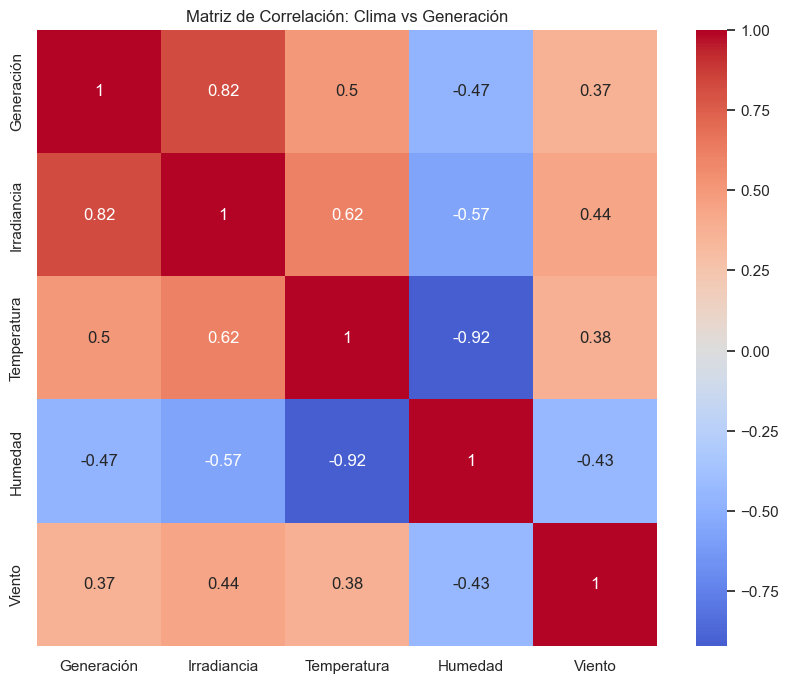

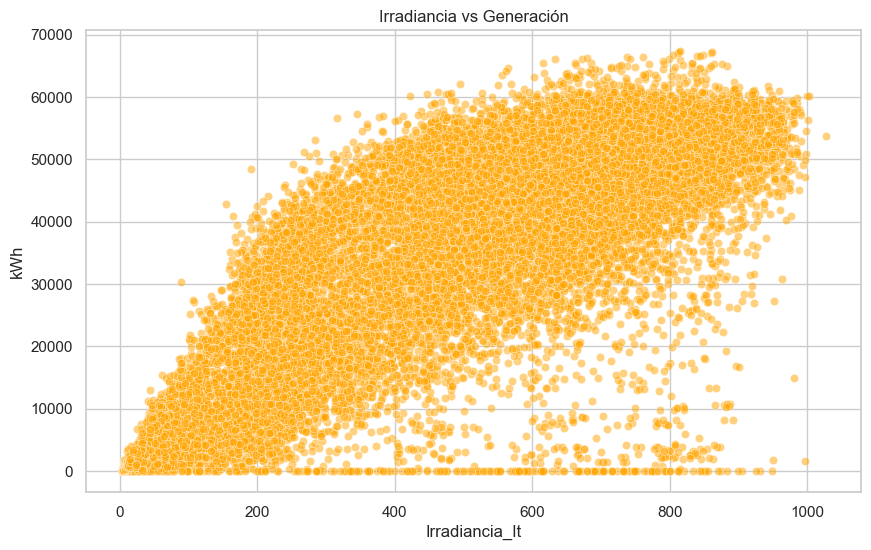

In [18]:
print("--- Iniciando Análisis de Correlación NASA-XM ---")
data_path = os.path.join(DATA_DIR, 'data-hourly.csv')
output_dir = os.path.join(EDA_DIR, 'NASA_xm_correlation')

df_corr_raw = pd.read_csv(data_path)
cols = {'kWh': 'Generación', 'Irradiancia_It': 'Irradiancia', 'Temperatura_Tt': 'Temperatura', 'Humedad_Ht': 'Humedad', 'Viento_Wt': 'Viento'}
df_corr = df_corr_raw[list(cols.keys())].rename(columns=cols)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title('Matriz de Correlación: Clima vs Generación')
plt.savefig(os.path.join(output_dir, '1_1_heatmap_correlacion.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr_raw, x='Irradiancia_It', y='kWh', alpha=0.5, color='orange')
plt.title('Irradiancia vs Generación')
plt.savefig(os.path.join(output_dir, 'scatter_irradiancia_vs_generacion.png'))
plt.show()